In [4]:
import pandas as pd

df = pd.read_csv("Planetary Data Composite Data - PSCompPars_2026.05.30_18.25.02.csv")

df.head()

,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007.0,Xinglong Station,0,323.21000,0.06,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008.0,Okayama Astrophysical Observatory,0,186.76000,0.11,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826
3,14 Her b,14 Her,1,2,Radial Velocity,2002.0,W. M. Keck Observatory,0,1766.41000,0.67,...,-0.0073,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996.0,Multiple Observatories,0,798.50000,1.00,...,-0.0111,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603


We use data from the NASA Exoplanet Archive to answer a few questions.

The first question I want to ask if there is a correlation between a planet's orbital period around its star and its radius.

Some background on this, Kepler's Third Law states that the square of the orbital period is proportional to the cube of it's semi major axis. Because of this law, we expect to see that a planet's orbital period is NOT affected by the planet's radius. We use the NASA Exoplanet Archive data to answer this.

In [13]:
# create subset with needed columns
plradius_orbper = df[["pl_name", "pl_orbper", "pl_rade", "pl_orbsmax"]]

# clean data

clean = plradius_orbper[['pl_orbper', 'pl_rade', "pl_orbsmax"]].dropna()

clean = clean[
    (clean['pl_orbper'] > 0) &
    (clean['pl_rade'] > 0) &
    (clean['pl_orbsmax'] > 0)
]

plradius_orbper.head()

,pl_name,pl_orbper,pl_rade,pl_orbsmax
0,11 Com b,323.21000,12.2,1.178
1,11 UMi b,516.21997,12.3,1.530
2,14 And b,186.76000,13.1,0.775
3,14 Her b,1766.41000,12.5,2.839
4,16 Cyg B b,798.50000,13.5,1.660


We first take the needed variables from the main database and create a new table with the needed information. This table is called 'plradius_orbper' which stands for the planet radius and its orbital period. The table contains three columns: 'pl_name', 'pl_orbper', and 'pl_rade'. The planet name, the planet orbital period in days, and the planet's radius in proportion to the Earth's radius.

In [6]:
# import plotting libraries
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
print((plradius_orbper[['pl_orbper','pl_rade']] <= 0).sum())

pl_orbper    0
pl_rade      0
dtype: int64


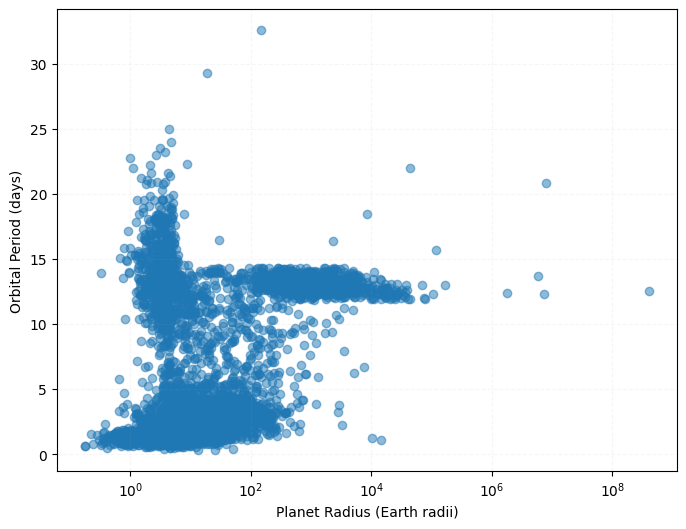

In [14]:
# plot data
plt.figure(figsize=(8,6))
plt.scatter(clean['pl_orbper'],clean['pl_rade'], alpha=0.5)


plt.xscale('log')  # important!
plt.xlabel("Planet Radius (Earth radii)")
plt.ylabel("Orbital Period (days)")

plt.grid(True, which="both", linestyle="--", alpha=0.1)
plt.show()

Plotting the data, we see that there is no clear correlation between the planet's radius and the planet's orbital period. We see that there are three major "clumps". Let's take a look at the bottom most "clump", planets with an earth radii of 10^0 to 10^2. For varying radii, from 10 times the Earth's size to 100 times the Earth's size, they have a similar orbital period from 0 days to 5 days, which is a wide variety.

Let us take a closer look at the correlation between these two by calculating the Pearson correlation coefficient.

In [19]:
# Correlation coefficients
corr_orb_rad = clean['pl_orbper'].corr(clean['pl_rade'])

print(corr_orb_rad)


0.019672585190595157


The Pearson correlation coefficient is 0.0196, which is close to 0. This value being close to 0 means that there is little to no correlation between the two variables.

Let's take a look at Kepler's Third Law once again: " the square of the orbital period is proportional to the cube of the semi-major axis (average radius). "

Instead of comparing the orbital distance and radius of the planet, let us actually compare the orbital period and the semi-major axis.

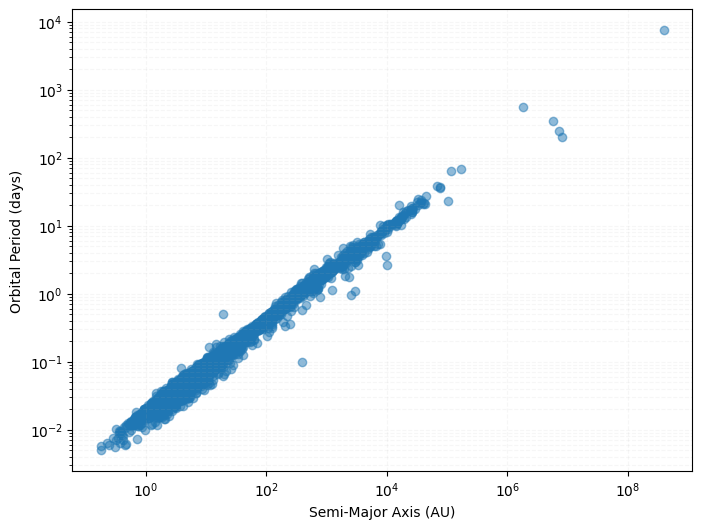

In [18]:
# Orbital distance and radius of planet

plt.figure(figsize=(8,6))
plt.scatter(clean['pl_orbper'],clean['pl_orbsmax'], alpha=0.5)


plt.yscale('log')  # important!
plt.xscale('log')  # important!
plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Orbital Period (days)")

plt.grid(True, which="both", linestyle="--", alpha=0.1)
plt.show()

We see that there is a clear line between the Semi-Major Axis of a planet's orbit and its orbital period. We can calculate Pearson's coefficient to see how correlated they are.

In [20]:
corr_orb_majax = clean['pl_orbper'].corr(clean['pl_orbsmax'])

print(corr_orb_majax)

0.9967090702880933


Pretty cool result! We see that the Pearson's coefficent is 0.9967, which is very very close to 1. This means there is a positive coefficient between the Semi-Major Axis of a planet's orbit and its orbital period, which is explained by Kepler's Third Law.